In [2]:
from getpass import getpass
import os

token = getpass("Paste Kaggle API token: ")

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write(token.strip())

!chmod 600 /root/.kaggle/access_token

Paste Kaggle API token: ··········


In [3]:
!pip install -q --upgrade kaggle

!kaggle competitions list

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 7.8 MB/s eta 0:00:00
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detect

In [4]:
import os
import zipfile
import glob

dataset_slug = "alistairking/weather-long-term-time-series-forecasting"
data_dir = "/content/weather_data"

os.makedirs(data_dir, exist_ok=True)

!kaggle datasets download -d alistairking/weather-long-term-time-series-forecasting -p /content/weather_data --force

zip_files = glob.glob(f"{data_dir}/*.zip")

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

print("Failai:")
for file in glob.glob(f"{data_dir}/*"):
    print(file)

Dataset URL: https://www.kaggle.com/datasets/alistairking/weather-long-term-time-series-forecasting
License(s): MIT
100% 2.11M/2.11M [00:00<00:00, 84.0MB/s]

Failai:
/content/weather_data/weather-long-term-time-series-forecasting.zip
/content/weather_data/cleaned_weather.csv


In [5]:
import pandas as pd
import glob

csv_files = glob.glob("/content/weather_data/*.csv")
print(csv_files)

df = pd.read_csv("/content/weather_data/cleaned_weather.csv")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
display(df.head())
print(df.columns)
print(df.dtypes)

['/content/weather_data/cleaned_weather.csv']
(52696, 21)


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


Index(['date', 'p', 'T', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh',
       'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR',
       'max. PAR', 'Tlog'],
      dtype='object')
date        datetime64[ns]
p                  float64
T                  float64
Tpot               float64
Tdew               float64
rh                 float64
VPmax              float64
VPact              float64
VPdef              float64
sh                 float64
H2OC               float64
rho                float64
wv                 float64
max. wv            float64
wd                 float64
rain               float64
raining            float64
SWDR               float64
PAR                float64
max. PAR           float64
Tlog               float64
dtype: object


Duomenų intervalas: 2020-01-01 00:10:00 → 2020-12-31 23:50:00
Eilučių kiekis: 52695
Koreliacija, visi matavimai: 0.45
Koreliacija, tik dienos šviesa SWDR > 10: 0.43
Koreliacija, dienos vidurkiai: 0.63


,Mėnuo,T_mean,SWDR_mean,T_max,SWDR_max
0,Sau,3.5,36.4,14.0,445.5
1,Vas,5.8,54.7,17.2,527.4
2,Kov,5.4,128.7,17.6,907.2
3,Bal,10.4,219.3,22.8,937.8
4,Geg,11.9,214.7,24.1,1115.3
5,Bir,17.4,213.3,29.4,1041.2
6,Lie,19.0,234.1,28.6,1066.8
7,Rgp,20.8,178.8,34.8,996.8
8,Rgs,15.4,154.6,30.2,964.5
9,Spa,10.9,65.4,20.6,684.7


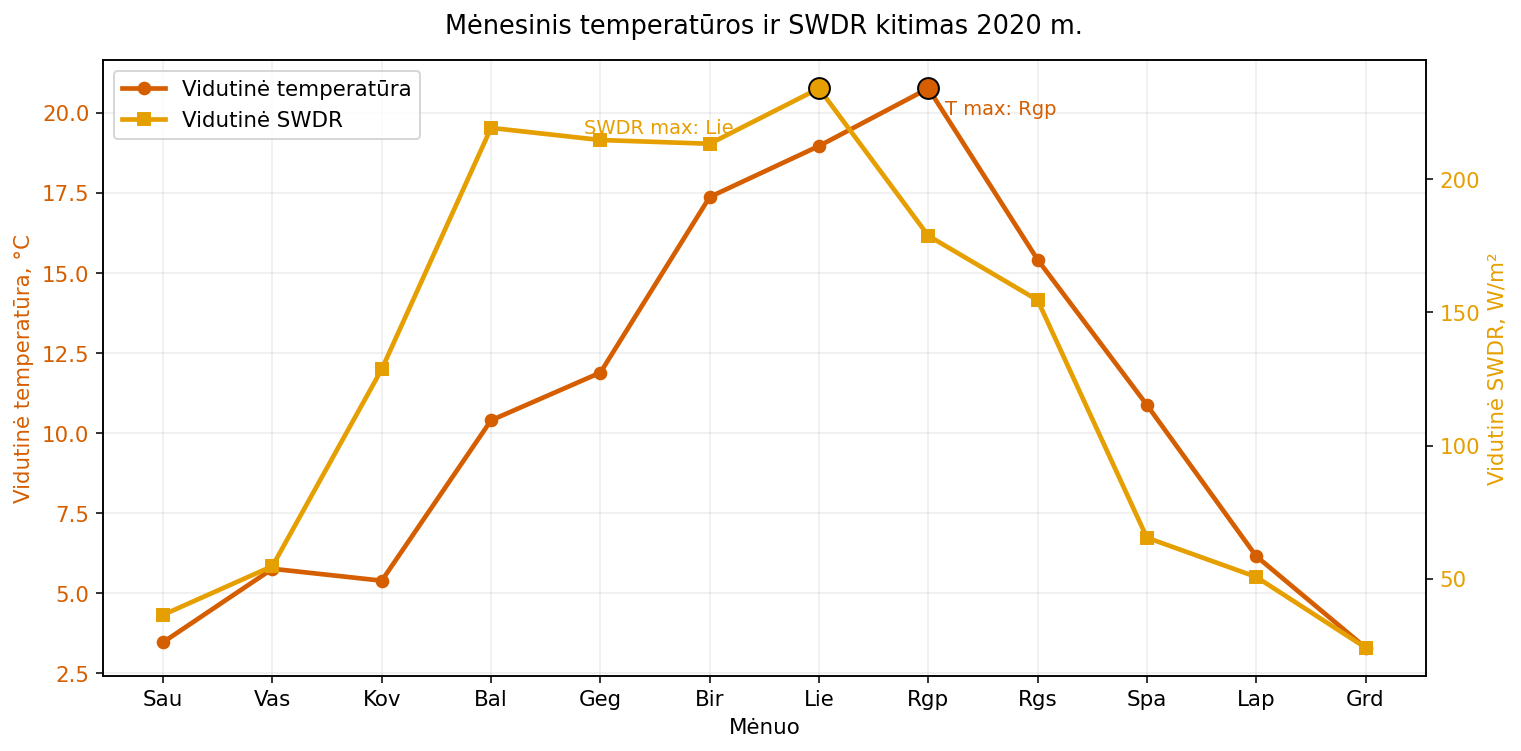

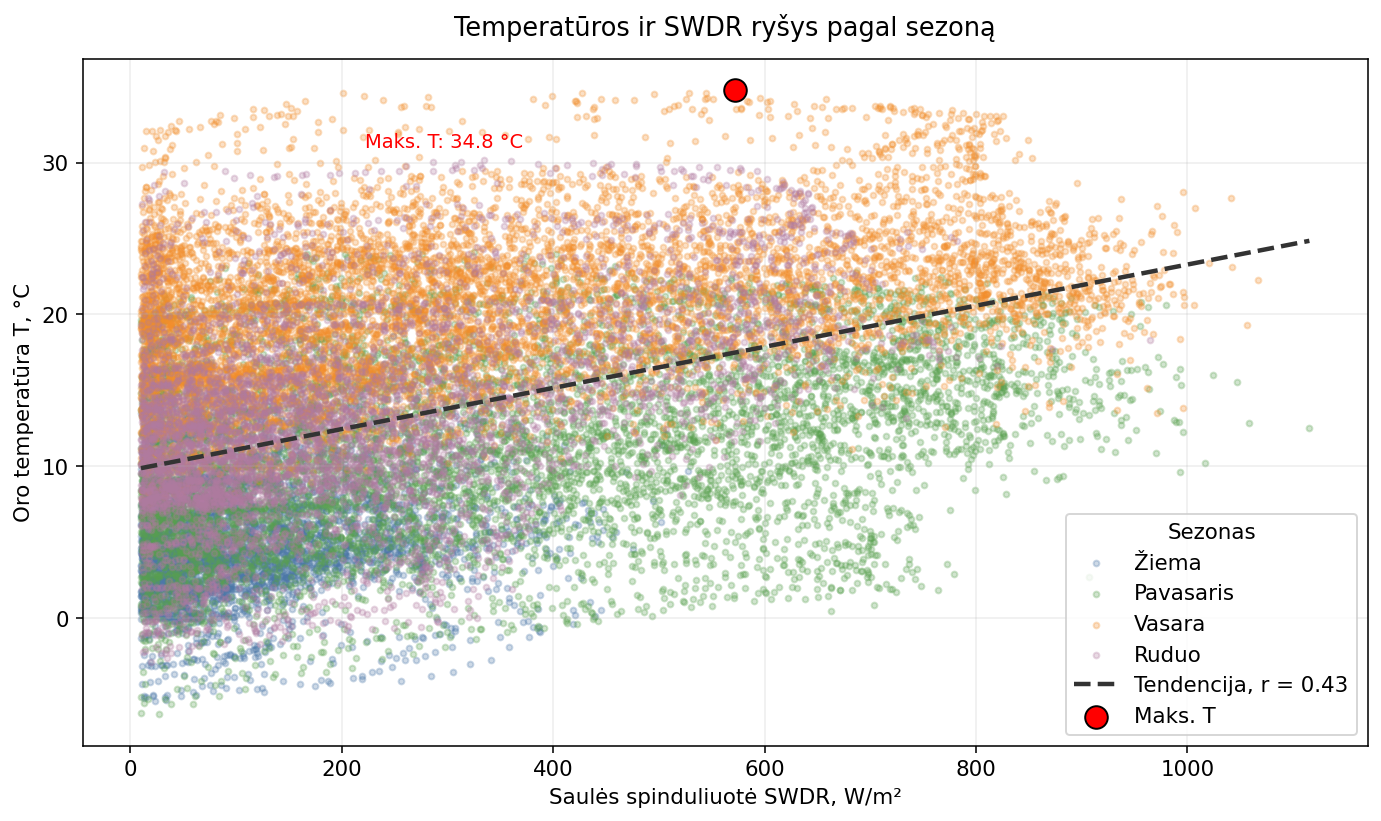

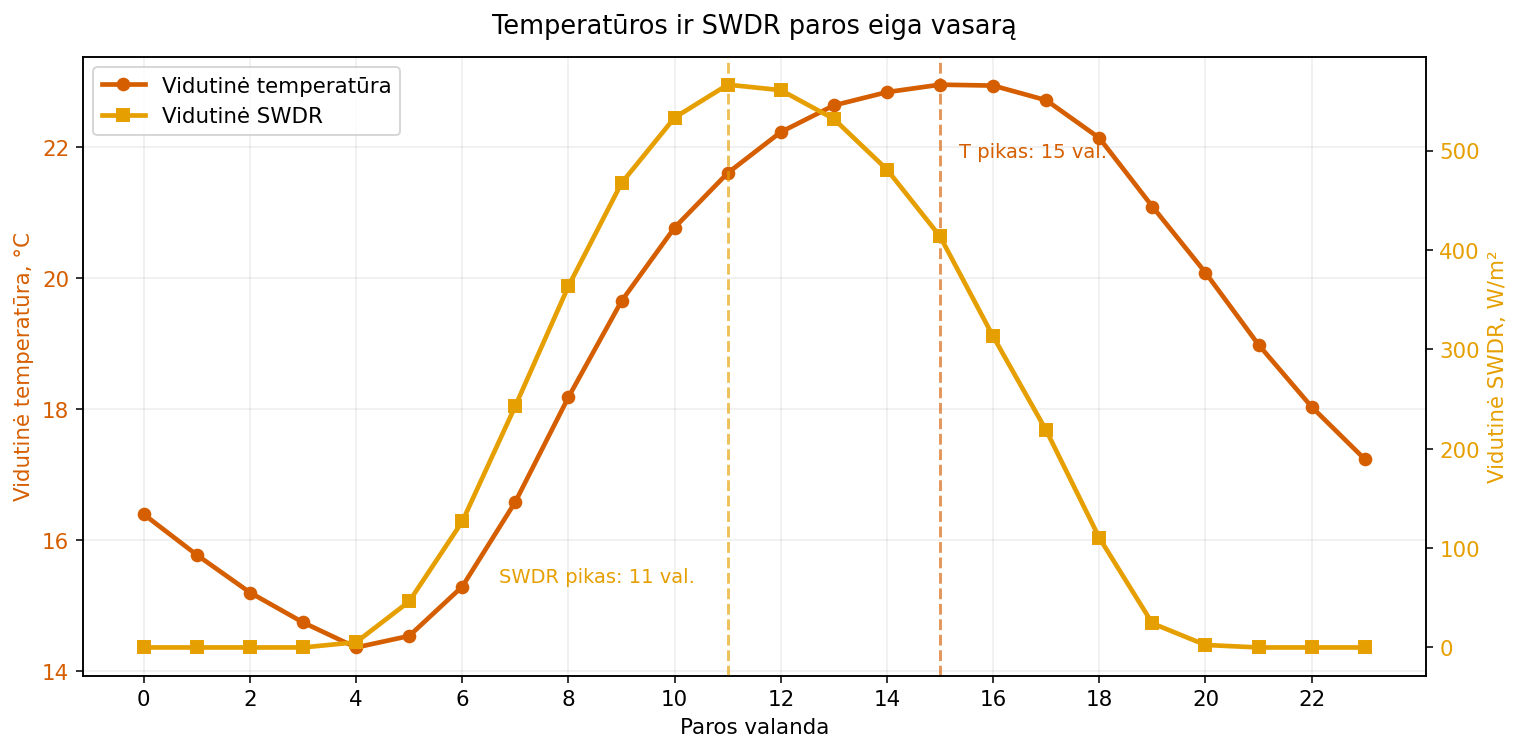

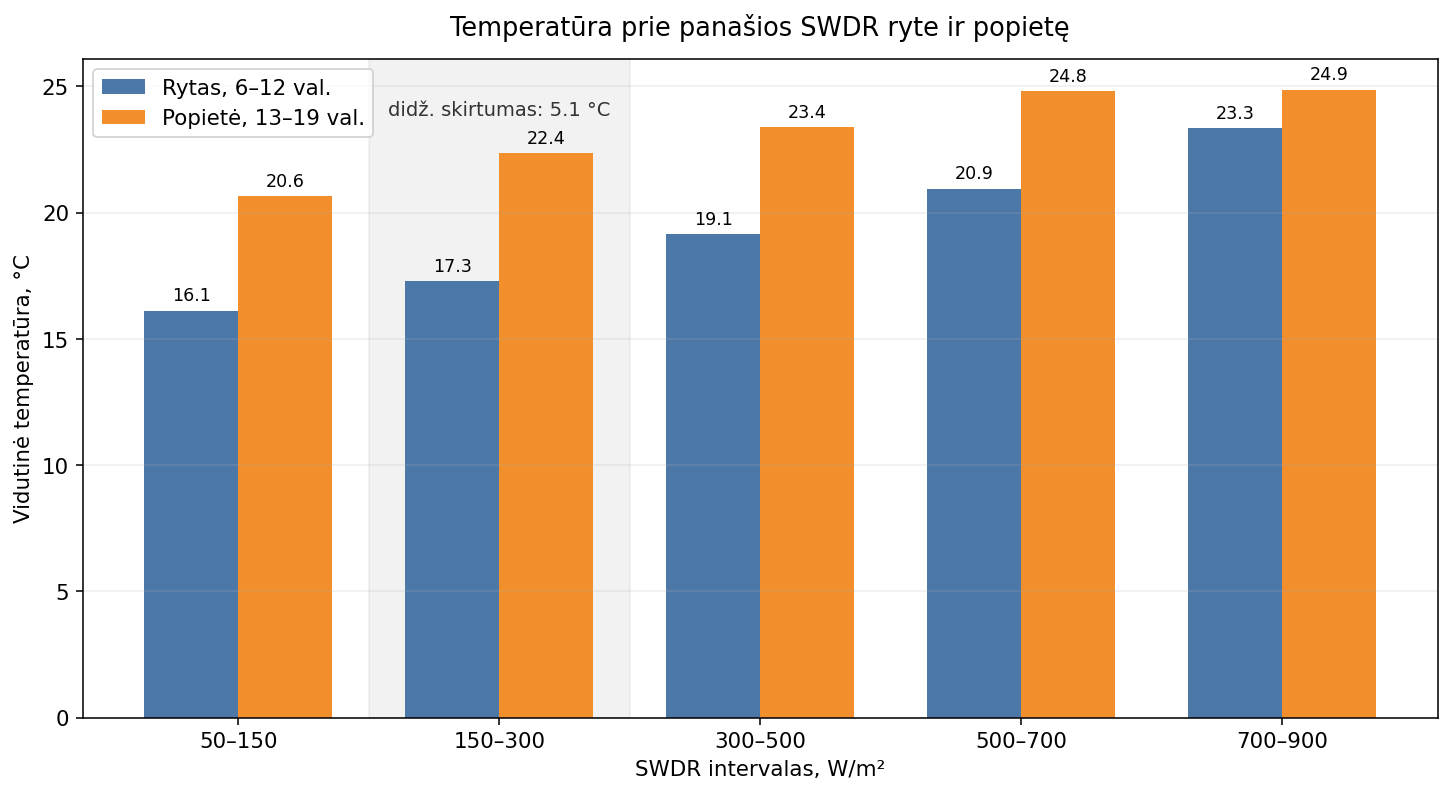

Išsaugoti grafikai:
/content/figures/01_monthly_T_SWDR.png
/content/figures/02_scatter_T_SWDR_season.png
/content/figures/03_summer_daily_cycle_lag.png
/content/figures/04_monthly_path_T_SWDR.png
/content/figures/04_morning_afternoon_same_SWDR.png
/content/figures/04_summer_loop_T_SWDR.png


In [11]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/content/weather_data/cleaned_weather.csv"

if not os.path.exists(DATA_PATH):
    matches = glob.glob("/content/**/*.csv", recursive=True)
    if len(matches) == 0:
        raise FileNotFoundError("CSV failas nerastas.")
    DATA_PATH = matches[0]

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df[df["date"].dt.year == 2020].copy()
df = df[["date", "T", "SWDR"]].dropna()

df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

month_labels = {
    1: "Sau", 2: "Vas", 3: "Kov", 4: "Bal",
    5: "Geg", 6: "Bir", 7: "Lie", 8: "Rgp",
    9: "Rgs", 10: "Spa", 11: "Lap", 12: "Grd"
}

def get_season(month):
    if month in [12, 1, 2]:
        return "Žiema"
    if month in [3, 4, 5]:
        return "Pavasaris"
    if month in [6, 7, 8]:
        return "Vasara"
    return "Ruduo"

df["season"] = df["month"].apply(get_season)

os.makedirs("/content/figures", exist_ok=True)

temp_color = "#D55E00"
sun_color = "#E69F00"
dark_color = "#333333"
morning_color = "#4C78A8"
afternoon_color = "#F28E2B"

season_colors = {
    "Žiema": "#4C78A8",
    "Pavasaris": "#59A14F",
    "Vasara": "#F28E2B",
    "Ruduo": "#B07AA1"
}

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 11

daily = (
    df.groupby(df["date"].dt.date)
      .agg(
          T_mean=("T", "mean"),
          SWDR_mean=("SWDR", "mean"),
          T_max=("T", "max"),
          SWDR_max=("SWDR", "max")
      )
      .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily["month"] = daily["date"].dt.month

monthly = (
    df.groupby("month")
      .agg(
          T_mean=("T", "mean"),
          SWDR_mean=("SWDR", "mean"),
          T_max=("T", "max"),
          SWDR_max=("SWDR", "max")
      )
      .reset_index()
)

daylight = df[df["SWDR"] > 10].copy()

raw_corr = df[["T", "SWDR"]].corr().iloc[0, 1]
daylight_corr = daylight[["T", "SWDR"]].corr().iloc[0, 1]
daily_corr = daily[["T_mean", "SWDR_mean"]].corr().iloc[0, 1]

print("Duomenų intervalas:", df["date"].min(), "→", df["date"].max())
print("Eilučių kiekis:", len(df))
print(f"Koreliacija, visi matavimai: {raw_corr:.2f}")
print(f"Koreliacija, tik dienos šviesa SWDR > 10: {daylight_corr:.2f}")
print(f"Koreliacija, dienos vidurkiai: {daily_corr:.2f}")

display(
    monthly.assign(Mėnuo=monthly["month"].map(month_labels))
           [["Mėnuo", "T_mean", "SWDR_mean", "T_max", "SWDR_max"]]
           .round(1)
)

fig, ax1 = plt.subplots(figsize=(11, 5.5))

ax1.plot(
    monthly["month"],
    monthly["T_mean"],
    marker="o",
    linewidth=2.4,
    color=temp_color,
    label="Vidutinė temperatūra"
)

ax1.set_xlabel("Mėnuo")
ax1.set_ylabel("Vidutinė temperatūra, °C", color=temp_color)
ax1.tick_params(axis="y", labelcolor=temp_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_labels[m] for m in range(1, 13)])

ax2 = ax1.twinx()

ax2.plot(
    monthly["month"],
    monthly["SWDR_mean"],
    marker="s",
    linewidth=2.4,
    color=sun_color,
    label="Vidutinė SWDR"
)

ax2.set_ylabel("Vidutinė SWDR, W/m²", color=sun_color)
ax2.tick_params(axis="y", labelcolor=sun_color)

max_t_idx = monthly["T_mean"].idxmax()
max_swdr_idx = monthly["SWDR_mean"].idxmax()

max_t_month = int(monthly.loc[max_t_idx, "month"])
max_swdr_month = int(monthly.loc[max_swdr_idx, "month"])

ax1.scatter(
    max_t_month,
    monthly.loc[max_t_idx, "T_mean"],
    s=115,
    color=temp_color,
    edgecolor="black",
    zorder=5
)

ax2.scatter(
    max_swdr_month,
    monthly.loc[max_swdr_idx, "SWDR_mean"],
    s=115,
    color=sun_color,
    edgecolor="black",
    zorder=5
)

ax1.text(
    max_t_month + 0.15,
    monthly.loc[max_t_idx, "T_mean"] - 0.8,
    f"T max: {month_labels[max_t_month]}",
    color=temp_color,
    fontsize=10
)

ax2.text(
    max_swdr_month - 2.15,
    monthly.loc[max_swdr_idx, "SWDR_mean"] - 17,
    f"SWDR max: {month_labels[max_swdr_month]}",
    color=sun_color,
    fontsize=10
)

ax1.set_title("Mėnesinis temperatūros ir SWDR kitimas 2020 m.", pad=14)
ax1.grid(True, alpha=0.22)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.savefig("/content/figures/01_monthly_T_SWDR.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

for season, color in season_colors.items():
    part = daylight[daylight["season"] == season]
    ax.scatter(
        part["SWDR"],
        part["T"],
        s=9,
        alpha=0.28,
        color=color,
        label=season
    )

x = daylight["SWDR"].values
y = daylight["T"].values

coef = np.polyfit(x, y, 1)
trend_x = np.linspace(x.min(), x.max(), 100)
trend_y = coef[0] * trend_x + coef[1]

ax.plot(
    trend_x,
    trend_y,
    color=dark_color,
    linewidth=2.3,
    linestyle="--",
    label=f"Tendencija, r = {daylight_corr:.2f}"
)

hottest = daylight.loc[daylight["T"].idxmax()]

ax.scatter(
    hottest["SWDR"],
    hottest["T"],
    s=135,
    color="red",
    edgecolor="black",
    zorder=5,
    label="Maks. T"
)

ax.text(
    hottest["SWDR"] - 350,
    hottest["T"] - 3.8,
    f"Maks. T: {hottest['T']:.1f} °C",
    color="red",
    fontsize=10
)

ax.set_title("Temperatūros ir SWDR ryšys pagal sezoną", pad=12)
ax.set_xlabel("Saulės spinduliuotė SWDR, W/m²")
ax.set_ylabel("Oro temperatūra T, °C")
ax.grid(True, alpha=0.22)
ax.legend(title="Sezonas", loc="lower right")

plt.tight_layout()
plt.savefig("/content/figures/02_scatter_T_SWDR_season.png", bbox_inches="tight")
plt.show()

summer = df[df["month"].isin([6, 7, 8])].copy()

summer_hourly = (
    summer.groupby("hour")
          .agg(
              T_mean=("T", "mean"),
              SWDR_mean=("SWDR", "mean")
          )
          .reset_index()
)

peak_t_hour = int(summer_hourly.loc[summer_hourly["T_mean"].idxmax(), "hour"])
peak_swdr_hour = int(summer_hourly.loc[summer_hourly["SWDR_mean"].idxmax(), "hour"])

fig, ax1 = plt.subplots(figsize=(11, 5.5))

ax1.plot(
    summer_hourly["hour"],
    summer_hourly["T_mean"],
    marker="o",
    linewidth=2.4,
    color=temp_color,
    label="Vidutinė temperatūra"
)

ax1.set_xlabel("Paros valanda")
ax1.set_ylabel("Vidutinė temperatūra, °C", color=temp_color)
ax1.tick_params(axis="y", labelcolor=temp_color)
ax1.set_xticks(range(0, 24, 2))

ax2 = ax1.twinx()

ax2.plot(
    summer_hourly["hour"],
    summer_hourly["SWDR_mean"],
    marker="s",
    linewidth=2.4,
    color=sun_color,
    label="Vidutinė SWDR"
)

ax2.set_ylabel("Vidutinė SWDR, W/m²", color=sun_color)
ax2.tick_params(axis="y", labelcolor=sun_color)

ax1.axvline(peak_t_hour, color=temp_color, linestyle="--", alpha=0.65)
ax2.axvline(peak_swdr_hour, color=sun_color, linestyle="--", alpha=0.65)

ax1.text(
    peak_swdr_hour - 4.3,
    summer_hourly["T_mean"].min() + 1.0,
    f"SWDR pikas: {peak_swdr_hour} val.",
    color=sun_color,
    fontsize=10
)

ax1.text(
    peak_t_hour + 0.35,
    summer_hourly["T_mean"].max() - 1.1,
    f"T pikas: {peak_t_hour} val.",
    color=temp_color,
    fontsize=10
)

ax1.set_title("Temperatūros ir SWDR paros eiga vasarą", pad=12)
ax1.grid(True, alpha=0.22)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.savefig("/content/figures/03_summer_daily_cycle_lag.png", bbox_inches="tight")
plt.show()

summer_compare = summer.copy()

summer_compare["day_part"] = np.select(
    [
        summer_compare["hour"].between(6, 12),
        summer_compare["hour"].between(13, 19)
    ],
    [
        "Rytas",
        "Popietė"
    ],
    default="Kita"
)

summer_compare = summer_compare[summer_compare["day_part"] != "Kita"].copy()
summer_compare = summer_compare[(summer_compare["SWDR"] >= 50) & (summer_compare["SWDR"] <= 900)].copy()

bins = [50, 150, 300, 500, 700, 900]
bin_labels = ["50–150", "150–300", "300–500", "500–700", "700–900"]

summer_compare["SWDR_intervalas"] = pd.cut(
    summer_compare["SWDR"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True,
    right=False
)

grouped = (
    summer_compare
    .groupby(["SWDR_intervalas", "day_part"], observed=True)
    .agg(
        T_mean=("T", "mean"),
        count=("T", "size")
    )
    .reset_index()
)

pivot = (
    grouped
    .pivot(index="SWDR_intervalas", columns="day_part", values="T_mean")
    .reindex(bin_labels)
)

count_pivot = (
    grouped
    .pivot(index="SWDR_intervalas", columns="day_part", values="count")
    .reindex(bin_labels)
)

diff = pivot["Popietė"] - pivot["Rytas"]
max_diff_idx = diff.idxmax()

x_pos = np.arange(len(pivot.index))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars_morning = ax.bar(
    x_pos - bar_width / 2,
    pivot["Rytas"],
    width=bar_width,
    color=morning_color,
    label="Rytas, 6–12 val."
)

bars_afternoon = ax.bar(
    x_pos + bar_width / 2,
    pivot["Popietė"],
    width=bar_width,
    color=afternoon_color,
    label="Popietė, 13–19 val."
)

for bars in [bars_morning, bars_afternoon]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.25,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

highlight_pos = list(pivot.index).index(max_diff_idx)

ax.axvspan(
    highlight_pos - 0.5,
    highlight_pos + 0.5,
    color="#999999",
    alpha=0.12,
    zorder=0
)

ax.text(
    highlight_pos,
    max(pivot.loc[max_diff_idx, "Rytas"], pivot.loc[max_diff_idx, "Popietė"]) + 1.5,
    f"didž. skirtumas: {diff.loc[max_diff_idx]:.1f} °C",
    ha="center",
    color=dark_color,
    fontsize=10
)

ax.set_title("Temperatūra prie panašios SWDR ryte ir popietę", pad=12)
ax.set_xlabel("SWDR intervalas, W/m²")
ax.set_ylabel("Vidutinė temperatūra, °C")
ax.set_xticks(x_pos)
ax.set_xticklabels(pivot.index)
ax.grid(axis="y", alpha=0.22)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("/content/figures/04_morning_afternoon_same_SWDR.png", bbox_inches="tight")
plt.show()

print("Išsaugoti grafikai:")
for file in sorted(os.listdir("/content/figures")):
    print("/content/figures/" + file)